In [27]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from moc_adjustment_theory import rossby_speed, EARTH_RADIUS_M, GlobalRossbyModel

In [28]:
isobath_ds = xr.open_dataset("/Users/awatford/Documents/GitHub/MOCAdjustmentTheory/data/tracked/isobath/global_isobath_GEBCO_1000m.nc")

### Creating the zonally averaged wind forcing
I am going to use zonally averaged winds over the sectors with direct influence on the Atlantic.
What this involves is:
1. Mask out the Indian and Pacific oceans;
2. Zonally averaging the wind forcing in each of the three remaining regions
3. Re-apply that wind forcing with zeros elsewhere

In [57]:
full_forcing_ds = xr.open_dataset("/Users/awatford/Documents/GitHub/MOCAdjustmentTheory/data/untracked/forcing/global_ERA5_SCOTIA_forcing_v4_taper-0_islands-1.nc")
full_forcing_ds = full_forcing_ds.sel(latitude=slice(-52, None)).sortby("latitude", ascending=True)

In [59]:
# Build the eastern and western boundary traces
x_w = isobath_ds.x_wA.dropna("latitude").sortby("latitude", ascending=True)
x_eA = isobath_ds.x_eA.dropna("latitude").sortby("latitude", ascending=True)
y_I = x_eA.latitude.min()
x_eI = isobath_ds.x_eI.dropna("latitude").sortby("latitude", ascending=True).sel(latitude=slice(None, y_I)).isel(latitude=slice(None, -1))
y_P = x_eI.latitude.min()
x_eP = isobath_ds.x_eP.dropna("latitude").sortby("latitude", ascending=True).sel(latitude=slice(None, y_P)).isel(latitude=slice(None, -1))
x_e = xr.concat([x_eP, x_eI, x_eA], dim="latitude").sortby("latitude", ascending=True)
x_w_on_forcing = x_w.interp(latitude=full_forcing_ds.latitude)
x_e_on_forcing = x_e.interp(latitude=full_forcing_ds.latitude)

In [ ]:
# Select the winds only within the Atlantic boundaries
mask = (full_forcing_ds.longitude >= x_w_on_forcing) & (full_forcing_ds.longitude <= x_e_on_forcing)
masked_forcing = full_forcing_ds.where(mask)
# Compute the zonal mean over the mask
zonal_avg_forcing = masked_forcing.mean(dim="longitude")
zonal_avg_forcing = zonal_avg_forcing.broadcast_like(full_forcing_ds).where(mask, other=0)
# Replace the T_N with the original T_N values
zonal_avg_forcing["T_N"] = full_forcing_ds["T_N"]

### Run the model with the zonally averaged forcing

In [61]:
model = GlobalRossbyModel(
    isobath_ds = isobath_ds,
    g_prime = 0.02,
)
solution = model.solve(zonal_avg_forcing)

### Diagnostics
First, we will look at $h_b$ directly.

In [62]:
# Extract h_b
h_b = solution.h_b.compute()
h_b_na = h_b.sel(region="north_atlantic").drop_vars("region").dropna(dim="latitude", how="all").sortby("latitude", ascending=True)
h_b_ai = h_b.sel(region="atlantic_indian").drop_vars("region").dropna(dim="latitude", how="all").sortby("latitude", ascending=True)
h_b_ap = h_b.sel(region="atlantic_pacific").drop_vars("region").dropna(dim="latitude", how="all").sortby("latitude", ascending=True)
h_b = xr.concat([h_b_ap, h_b_ai, h_b_na], dim="latitude").sortby("latitude", ascending=True)

(-52.0, 55.0)

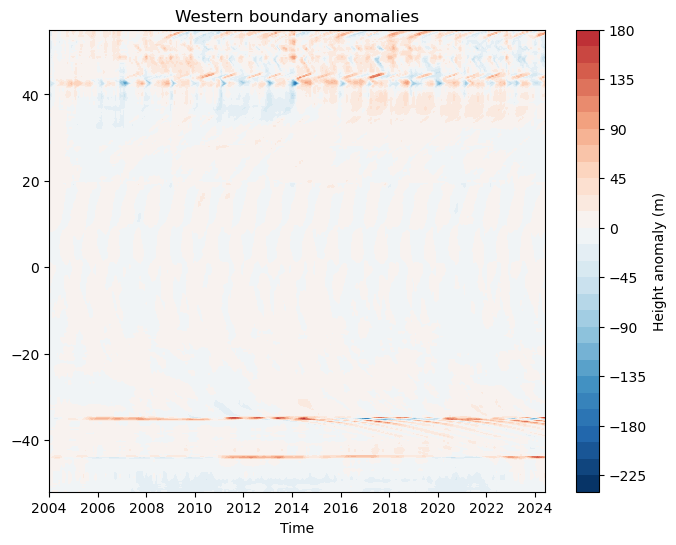

In [65]:
## Plot the western boundary anomalies in the Atlantic
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
# Plot height anomalies
vmax = np.max(np.abs(h_b.T))
ctf = ax.contourf(h_b.time, h_b.latitude, h_b.T, cmap="RdBu_r", levels=31, vmin=-vmax, vmax=vmax)
ax.set_xlabel("Time")
plt.colorbar(ctf, ax=ax, label="Height anomaly (m)")
ax.set_title("Western boundary anomalies")
ax.set_ylim([h_b.latitude.min(), h_b.latitude.max()])

The magnitude of the variability in latitude and time is somewhat similar. Next we examine our $\alpha$ factor.

In [78]:
# Compute the Ekman upwelling as the divergence of the forcing
x_contribution = zonal_avg_forcing.M_Ek_x.differentiate("longitude") / (EARTH_RADIUS_M * np.cos(np.radians(zonal_avg_forcing.latitude)) * np.radians(1))
y_contribution = (zonal_avg_forcing.M_Ek_y * np.cos(np.radians(zonal_avg_forcing.latitude))).differentiate("latitude") / (EARTH_RADIUS_M * np.cos(np.radians(zonal_avg_forcing.latitude)) * np.radians(1))
w_Ek = (x_contribution + y_contribution)
# Mask the upwelling only to the Atlantic basin
w_Ek_atlantic = w_Ek.where(mask)
zonal_mean_w_Ek_std = w_Ek_atlantic.std(dim="time").mean(dim="longitude")
# Compute the variability in h_b as a function of latitude
h_b_std = h_b.std(dim="time")
# Compute the travel times
g = solution.attrs["g_prime_m_s-2"]
H = solution.attrs["isobath_depth_m"]
L = EARTH_RADIUS_M * np.cos(np.radians(x_w.latitude)) * np.radians(x_e - x_w)
c = rossby_speed(L.latitude, g, H)
tt = L / c
# Product of travel time and Ekman upwelling variability
tt_on_forcing = tt.interp(latitude=zonal_mean_w_Ek_std.latitude)
tau_times_w_Ek_std = tt_on_forcing * zonal_mean_w_Ek_std
tau_times_w_Ek_std = tau_times_w_Ek_std.interp(latitude=h_b_std.latitude)

Text(0, 0.5, 'Latitude (°N)')

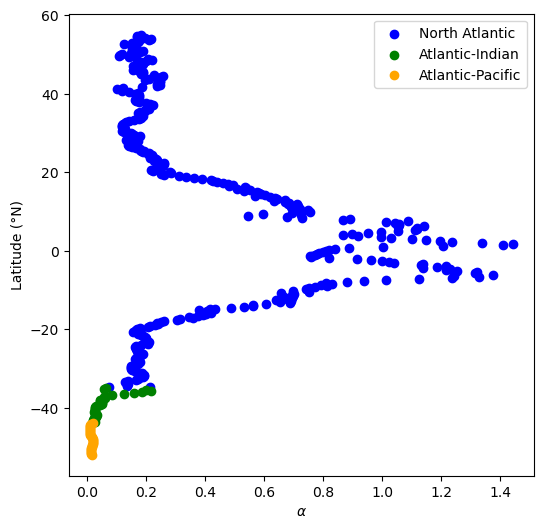

In [80]:
alpha = h_b_std / tau_times_w_Ek_std
alpha_NA = alpha.sel(latitude=slice(y_I, None))
alpha_AI = alpha.sel(latitude=slice(y_P, y_I))
alpha_AP = alpha.sel(latitude=slice(None, y_P))
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)
ax.scatter(alpha_NA.values, alpha_NA.latitude.values, label="North Atlantic", color="blue")
ax.scatter(alpha_AI.values, alpha_AI.latitude.values, label="Atlantic-Indian", color="green")
ax.scatter(alpha_AP.values, alpha_AP.latitude.values, label="Atlantic-Pacific", color="orange")
ax.legend()
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("Latitude (\N{DEGREE SIGN}N)")

Notice that the range of $\alpha$ values has shifted somewhat, now upper bounded by 1.4 as opposed to 1.0. This suggests that zonal structure does have some role to play. However, the general latitudinal structure of $\alpha$ seems to be set by the latitude and temporal structure of the wind field. Consider a map of the upwelling. We see that the variability peaks just north of the equator (ITCZ), and that there are stronger Northern Hemisphere winds in the high latitudes but not so much in the southern latitudes. The symmetry in $\alpha$ around $20-30$ degrees on either side of the equator is somewhat reflected in the $w_{Ek}$ profile, but the continuance of $\alpha \approx 0.2$ north of $30$ N is not easily explained by just looking at $w_{Ek}$.

### Next Steps:
Even though we have a pretty good idea of what the results will look like, we will start looking at the effects of localized wind bursts.